In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load raw data

In [103]:
df = pd.read_csv('../data/raw/credit_data_poor.csv')

### Check data types
Incorrect data types could indicate errors in data.

In [121]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   distance_from_home              10000 non-null  float64
 1   distance_from_last_transaction  10000 non-null  float64
 2   ratio_to_median_purchase_price  10000 non-null  float64
 3   repeat_retailer                 10000 non-null  int64  
 4   used_chip                       10000 non-null  int64  
 5   used_pin_number                 10000 non-null  int64  
 6   online_order                    10000 non-null  int64  
 7   fraud                           10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,26.374744,4.807107,1.824164,0.879000,0.350800,0.104800,0.641500,0.084100
std,58.811106,22.260124,2.762438,0.326144,0.477244,0.306311,0.479584,0.277552
min,0.049270,0.000930,0.011373,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.808606,0.305219,0.489052,1.000000,0.000000,0.000000,0.000000,0.000000
50%,10.026888,1.006459,1.005754,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.866217,3.313696,2.091252,1.000000,1.000000,0.000000,1.000000,0.000000
max,2033.498174,990.070315,65.150879,1.000000,1.000000,1.000000,1.000000,1.000000


### Check for missing data
If there are missing values, fill or remove during data preparation. 

In [105]:
df.isna().sum()

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

### Check for duplicates
If there are duplicates, remove or manage during data preparation.

In [106]:
df.duplicated().any()

np.False_

In [107]:
df[df.duplicated()]

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud


### Check for outliers
Do not remove during data preparation. Outliers are crutial for detecting anomalies such as fraud transactions.

In [120]:
cont_cols, binary_cols, cat_cols = [], [], []

for col in df.columns:
    if df[col].dtype == "object":
        cat_cols.append(col)
    else:
        if df[col].nunique() > 2:
            cont_cols.append(col)
        elif col != "fraud":
            binary_cols.append(col)

print("Binary Columns:", binary_cols)
print("Continous Columns:", cont_cols)
print("Categorical Columns:", cat_cols)

Binary Columns: ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']
Continous Columns: ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']
Categorical Columns: []


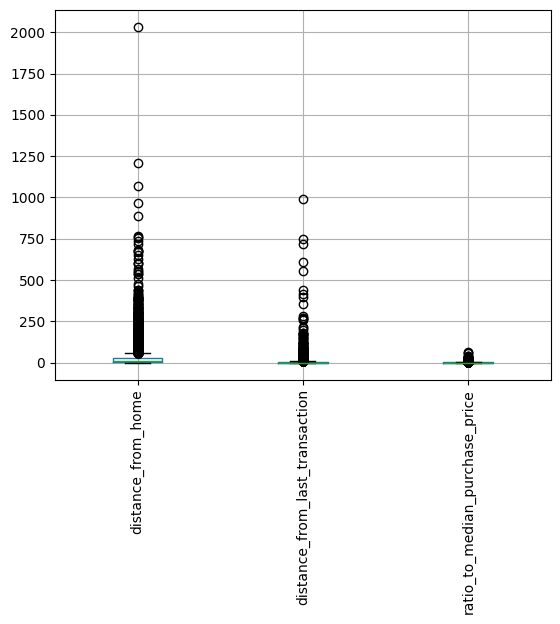

In [109]:
df[cont_cols].boxplot()
plt.xticks(rotation=90)
plt.show()

### Check class distribution
If classes are imbalanced, avoid using Accuracy metric. Use F1 Score, Percision and Recall instead to measure model preformance.

In [110]:
# count values of classifier column
counts = df['fraud'].map({0: "No", 1: "Yes"}).value_counts()
counts

fraud
No     9159
Yes     841
Name: count, dtype: int64

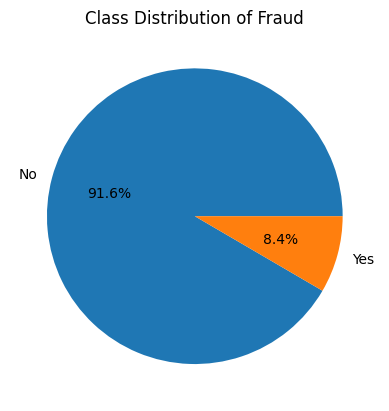

In [111]:
# pie chart
counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Class Distribution of Fraud')
plt.show()

### Visual inspection
Scan though the data breifly looking for any other issues. 

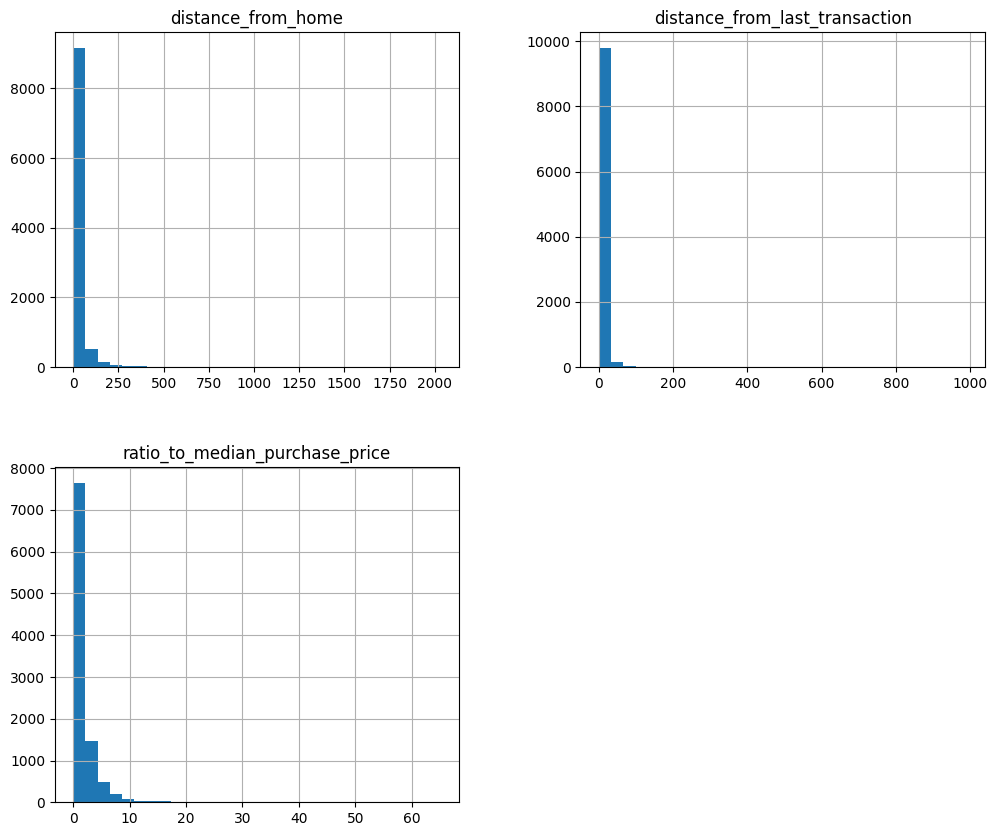

In [122]:
cont_cols, binary_cols = [], []

for col in df.columns:
    if df[col].nunique() > 2:
        cont_cols.append(col)
    else:
        binary_cols.append(col)

df[cont_cols].hist(figsize=(12, 10), bins=30)
plt.show()

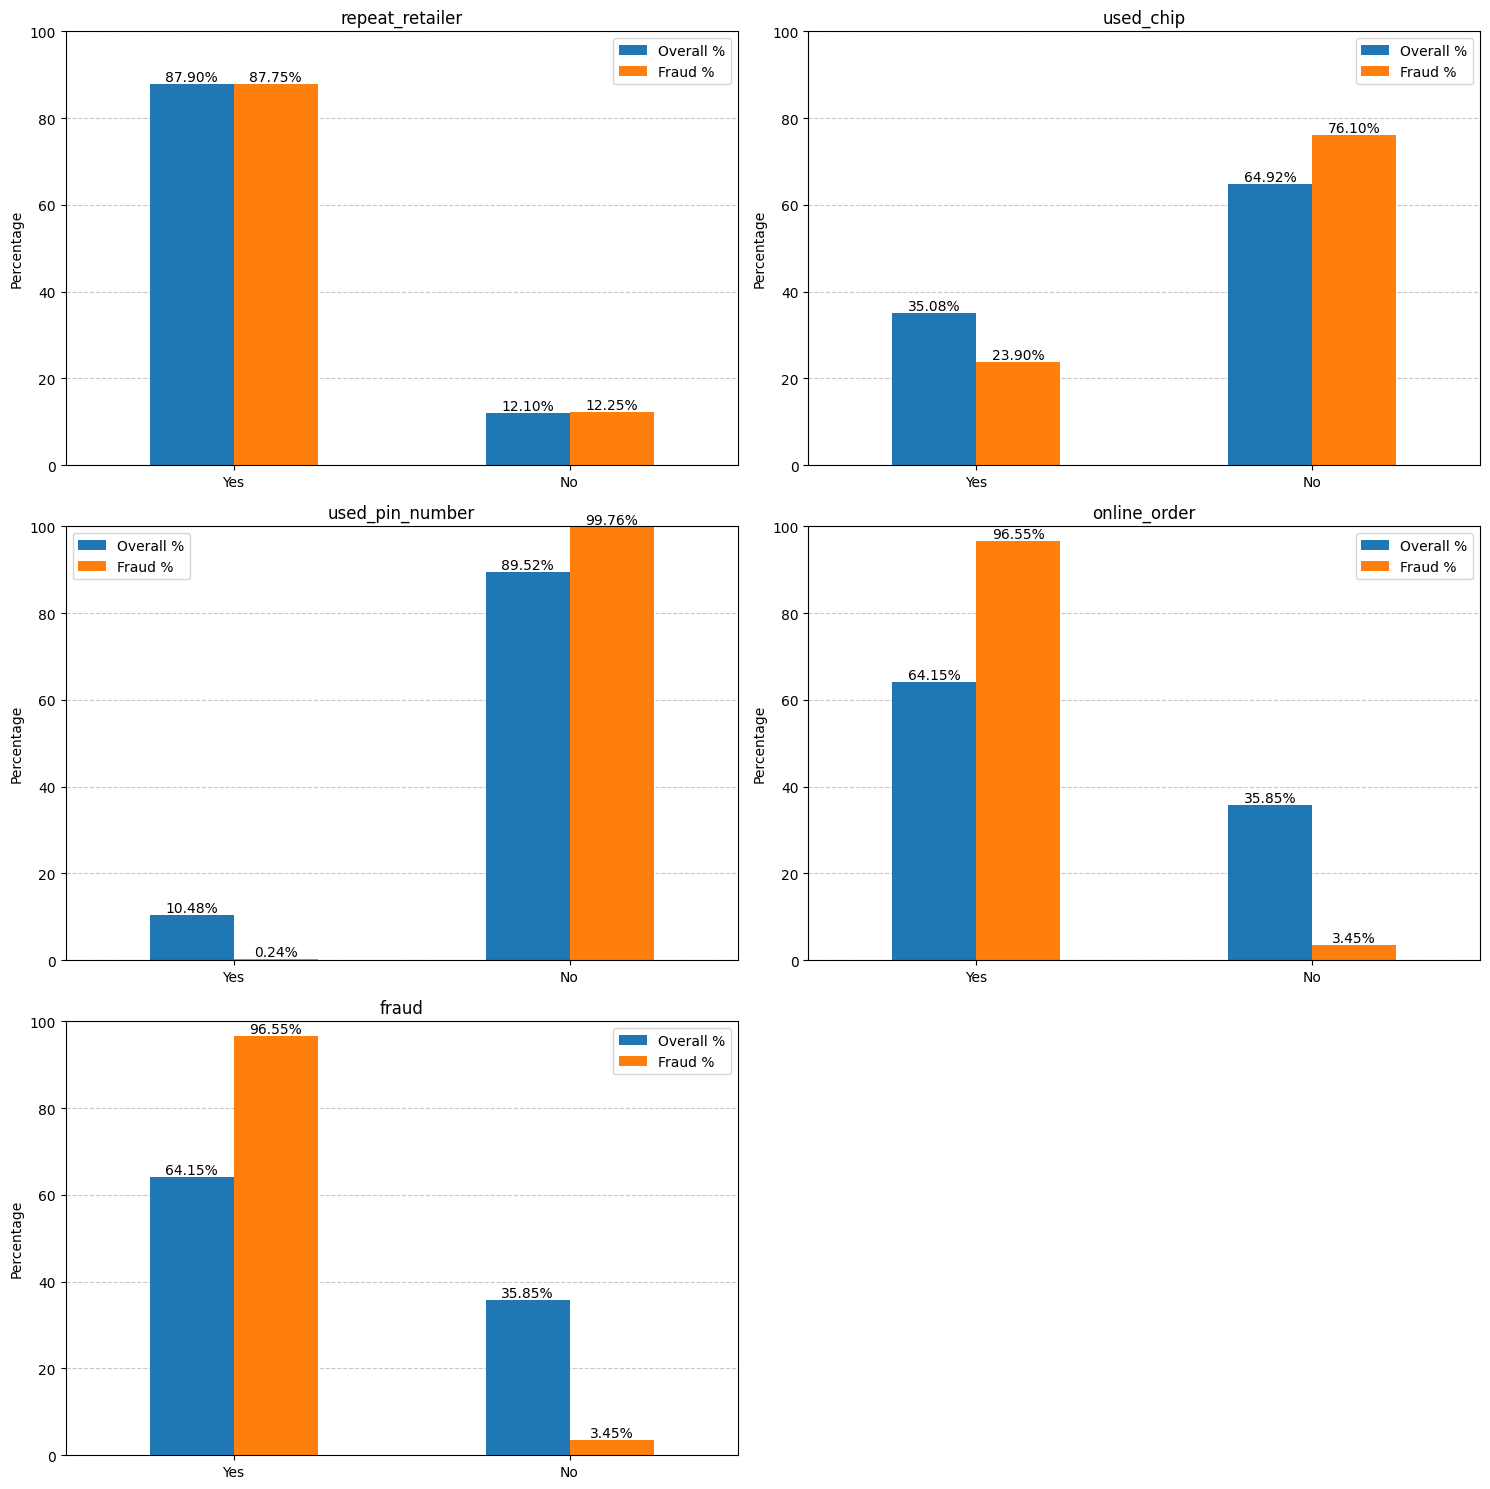

In [ ]:
n_rows = int(np.ceil(len(binary_cols) / 2))

fig, axes = plt.subplots(int(n_rows), 2, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, binary_cols):
    overall = df[col].map({0: "No", 1: "Yes"}).value_counts(normalize=True)
    overall = overall.reindex(["Yes", "No"], fill_value=0) * 100

    fraud_rate = df[df['fraud'] == 1][col].map({0: "No", 1: "Yes"}).value_counts(normalize=True)
    fraud_rate = fraud_rate.reindex(["Yes", "No"], fill_value=0) * 100

    plot_df = pd.DataFrame({
        "Overall %": overall,
        "Fraud %": fraud_rate
    })

    plot_df.plot(kind='bar', ax=ax)
    ax.set_title(col)

    ax.set_ylim(0, 100)
    ax.grid(axis='y', linestyle="--", alpha=0.7)
    ax.set_axisbelow(True)
    ax.set_ylabel("Percentage")

    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=0)

    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.2f%%")

for j in range(len(binary_cols), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

In [114]:
# Remove any identifier columns (When dataset is chosen)
# col_df = df.remove

### Variance Calculation


In [115]:
col_var = df.var()
print(col_var)

distance_from_home                3458.746144
distance_from_last_transaction     495.513142
ratio_to_median_purchase_price       7.631065
repeat_retailer                      0.106370
used_chip                            0.227762
used_pin_number                      0.093826
online_order                         0.230001
fraud                                0.077035
dtype: float64


### Correlation Calculation and Visualisation
Sees if any two features have a linear relationship.

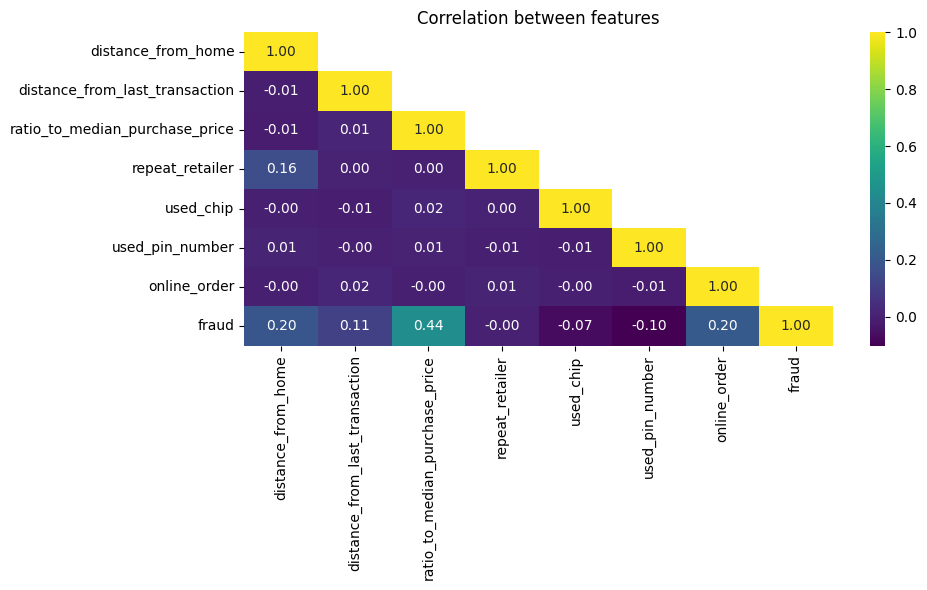

In [116]:
cor_cof= df.corr()
mask = np.triu(np.ones_like(cor_cof, dtype=bool), k=1) # Correlation is symmetric, so we only need to show one triangle of the matrix

plt.figure(figsize=(10, 6))
sns.heatmap(cor_cof, mask=mask, annot=True, cmap="viridis", fmt=".2f", xticklabels=df.columns, yticklabels=df.columns)
plt.title("Correlation between features")
plt.tight_layout()
plt.show()


In [117]:
target_corr = cor_cof['fraud']
target_corr_cont = target_corr[cont_cols]

top2_vals = target_corr_cont.abs().sort_values(ascending=False)[1:3] #Find the top 2 features most correlated with fraud
print(top2_vals)

top2_features = top2_vals.index.to_list()

distance_from_home                0.195015
distance_from_last_transaction    0.109744
Name: fraud, dtype: float64


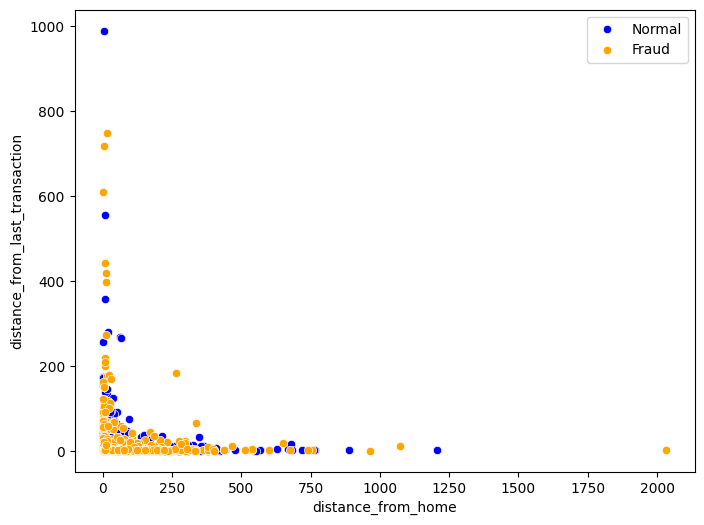

In [118]:
f1, f2 = top2_features

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df[df['fraud'] == 0][f1],
    y=df[df['fraud'] == 0][f2],
    color="blue",
    label="Normal",
)

sns.scatterplot(
    x=df[df['fraud'] == 1][f1],
    y=df[df['fraud'] == 1][f2],
    color="orange",
    label="Fraud",
)
plt.show()

### Before data preparation

*Feature selection* - Are there features with no significance or zero variance?

*Feature scaling* - Are there numerical features with vastly different ranges?

*Data leakage* - Are there features that would not be available at the time of prediction but perfectly predict the output?

*Stratification* - Will the percentage of each class be roughly the same across data splits?

*Order* - Is your data time based? Can you shuffle it?

*Hidden bias* - Does data accurately represent the real world?
